# 01 · FastF1 EDA - what data do we actually have?

In [26]:
# Run from the repo root so `import src...` works and FastF1 uses data/cache/.
import os
import sys
from pathlib import Path

if Path.cwd().name == "notebooks":
    os.chdir(Path.cwd().parent)
sys.path.insert(0, str(Path.cwd()))

import logging

import fastf1
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.data.ingestion import LAP_COLUMNS, filter_clean_laps, load_session

fastf1.set_log_level("ERROR")
logging.getLogger("fastf1").setLevel(logging.ERROR)
pd.set_option("display.max_columns", 40, "display.width", 200)

# Plot style: thin marks, recessive grid, no top/right spines.
plt.rcParams.update({
    "figure.figsize": (11, 4), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e4e3df", "grid.linewidth": 0.8,
    "axes.edgecolor": "#8a8984", "axes.labelcolor": "#52514e",
    "xtick.color": "#52514e", "ytick.color": "#52514e",
    "axes.titleweight": "bold", "axes.titlesize": 12, "lines.linewidth": 2,
    "legend.frameon": False,
})
# Categorical slots (fixed order) for drivers; compounds use F1's own convention.
DRIVER_COLORS = {"VER": "#2a78d6", "HAM": "#eb6834", "ALO": "#1baf7a"}
COMPOUND_COLORS = {"SOFT": "#e34948", "MEDIUM": "#eda100", "HARD": "#8a8984",
                   "INTERMEDIATE": "#008300", "WET": "#2a78d6"}

In [27]:
session = load_session(2023, "Bahrain", "R", weather=True, telemetry=True)
print(session.event["EventName"], session.event["EventDate"].date(), "| scheduled laps:", session.total_laps)

Bahrain Grand Prix 2023-03-05 | scheduled laps: 57


## 1 · The lap table - every column FastF1 gives us

Below: every column, its dtype, how often it is missing, and whether we currently keep it.

In [28]:
laps = pd.DataFrame(session.laps)
overview = pd.DataFrame({
    "dtype": laps.dtypes.astype(str),
    "missing_%": (laps.isna().mean() * 100).round(1),
    "n_unique": laps.nunique(),
    "example": laps.iloc[10],
    "kept_in_phase1": [c in LAP_COLUMNS for c in laps.columns],
})
print(laps.shape)
overview

(1056, 31)


,dtype,missing_%,n_unique,example,kept_in_phase1
Time,timedelta64[ns],0.0,1056,0 days 01:20:37.184000,False
Driver,object,0.0,20,VER,True
DriverNumber,object,0.0,20,1,False
LapTime,timedelta64[ns],0.1,966,0 days 00:01:38.483000,True
LapNumber,float64,0.0,57,11.0,True
Stint,float64,0.0,7,1.0,True
PitOutTime,timedelta64[ns],95.3,50,NaT,True
PitInTime,timedelta64[ns],95.1,52,NaT,True
Sector1Time,timedelta64[ns],2.0,722,0 days 00:00:31.342000,False
Sector2Time,timedelta64[ns],0.1,849,0 days 00:00:42.978000,False


**Things to notice**

* `LapTime`, `Sector*Time` are **`timedelta64`**, not floats → `.dt.total_seconds()` before maths.
* `LapNumber`, `Stint`, `TyreLife` are floats in FastF1 (because of NaN); after our Parquet round-trip they become nullable ints.
* `PitInTime` / `PitOutTime` are **mostly missing by design**.
* Columns we currently drop that could become features later: `Sector1-3Time` (coarse sector pace),
  `SpeedI1/I2/FL/ST` (speed-trap readings), `FreshTyre`, `Position`.
* `Time` = session time at the **end** of the lap; `LapStartTime` = at the start. Using `Time` to join weather would leak the future.

In [29]:
laps[["Driver", "LapNumber", "LapTime", "Sector1Time", "Sector2Time", "Sector3Time",
      "Compound", "TyreLife", "Stint", "PitInTime", "PitOutTime", "TrackStatus", "Position"]].query("Driver == 'VER'").head(16)

,Driver,LapNumber,LapTime,Sector1Time,Sector2Time,Sector3Time,Compound,TyreLife,Stint,PitInTime,PitOutTime,TrackStatus,Position
0,VER,1.0,0 days 00:01:39.019000,NaT,0 days 00:00:42.414000,0 days 00:00:23.842000,SOFT,4.0,1.0,NaT,NaT,12,1.0
1,VER,2.0,0 days 00:01:37.974000,0 days 00:00:31.342000,0 days 00:00:42.504000,0 days 00:00:24.128000,SOFT,5.0,1.0,NaT,NaT,12,1.0
2,VER,3.0,0 days 00:01:38.006000,0 days 00:00:31.388000,0 days 00:00:42.469000,0 days 00:00:24.149000,SOFT,6.0,1.0,NaT,NaT,1,1.0
3,VER,4.0,0 days 00:01:37.976000,0 days 00:00:31.271000,0 days 00:00:42.642000,0 days 00:00:24.063000,SOFT,7.0,1.0,NaT,NaT,1,1.0
4,VER,5.0,0 days 00:01:38.035000,0 days 00:00:31.244000,0 days 00:00:42.724000,0 days 00:00:24.067000,SOFT,8.0,1.0,NaT,NaT,1,1.0
5,VER,6.0,0 days 00:01:37.986000,0 days 00:00:31.341000,0 days 00:00:42.632000,0 days 00:00:24.013000,SOFT,9.0,1.0,NaT,NaT,1,1.0
6,VER,7.0,0 days 00:01:38.021000,0 days 00:00:31.290000,0 days 00:00:42.763000,0 days 00:00:23.968000,SOFT,10.0,1.0,NaT,NaT,1,1.0
7,VER,8.0,0 days 00:01:38.154000,0 days 00:00:31.291000,0 days 00:00:42.833000,0 days 00:00:24.030000,SOFT,11.0,1.0,NaT,NaT,1,1.0
8,VER,9.0,0 days 00:01:38.278000,0 days 00:00:31.336000,0 days 00:00:42.823000,0 days 00:00:24.119000,SOFT,12.0,1.0,NaT,NaT,1,1.0
9,VER,10.0,0 days 00:01:38.369000,0 days 00:00:31.361000,0 days 00:00:42.884000,0 days 00:00:24.124000,SOFT,13.0,1.0,NaT,NaT,1,1.0


## 2 · Why we filter laps - the lap-time distribution

Pit laps, lap 1 and neutralised laps are much slower and would dominate any
average or regression. Compare all laps with what `filter_clean_laps` + green flag leaves.

count    1055.00
mean      100.45
std         6.15
min        94.00
25%        97.75
50%        98.61
75%       100.24
max       138.69


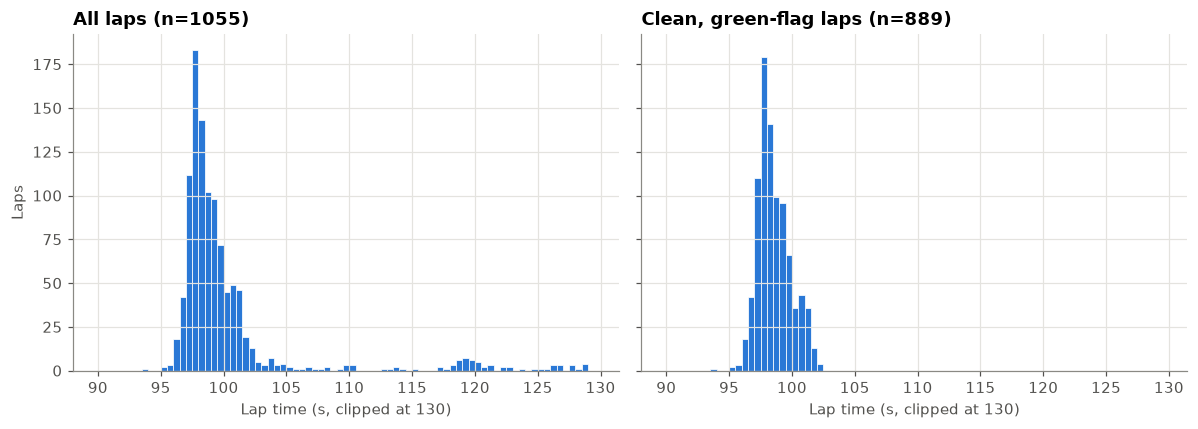

In [30]:
laps["LapTime_s"] = laps["LapTime"].dt.total_seconds()
clean = filter_clean_laps(laps)
clean_green = clean[clean["TrackStatus"] == "1"]

fig, axes = plt.subplots(1, 2, sharey=True)
bins = np.arange(90, 130, 0.5)
for ax, df, title in [(axes[0], laps, f"All laps (n={laps['LapTime_s'].notna().sum()})"),
                      (axes[1], clean_green, f"Clean, green-flag laps (n={len(clean_green)})")]:
    ax.hist(df["LapTime_s"].clip(upper=129.9), bins=bins, color="#2a78d6", edgecolor="white", linewidth=0.5)
    ax.set_title(title, loc="left")
    ax.set_xlabel("Lap time (s, clipped at 130)")
axes[0].set_ylabel("Laps")
plt.tight_layout()
print(laps["LapTime_s"].describe().round(2).to_string())

In [31]:
# TrackStatus is a STRING of every status code seen during the lap, e.g. "126".
# 1 green · 2 yellow · 4 Safety Car · 5 red flag · 6 VSC deployed · 7 VSC ending
laps["TrackStatus"].value_counts().rename_axis("TrackStatus").to_frame("laps")

,laps
TrackStatus,
1,979
12,26
21,19
126,14
671,13
2671,5


## 3 · Race trace - lap time over the race

Each line is one driver. Spikes are pit stops (in-lap + out-lap); the gentle
downward drift within a stint is **fuel burn** (lighter car), and the upward
drift is **tyre wear**. Those two effects fight each other - that is exactly what
`fuel_corrected_lap_time` untangles.

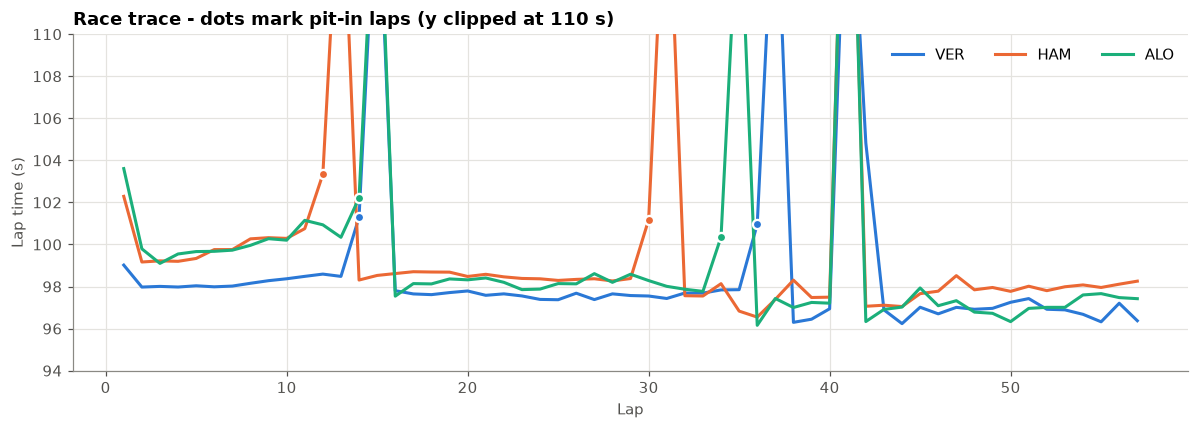

In [32]:
fig, ax = plt.subplots()
for drv, color in DRIVER_COLORS.items():
    d = laps[laps["Driver"] == drv].sort_values("LapNumber")
    ax.plot(d["LapNumber"], d["LapTime_s"], color=color, label=drv)
    pits = d[d["PitInTime"].notna()]
    ax.scatter(pits["LapNumber"], pits["LapTime_s"].clip(upper=109.5), s=36, color=color,
               edgecolor="white", linewidth=1.5, zorder=3)
ax.set_ylim(94, 110)
ax.set_xlabel("Lap"); ax.set_ylabel("Lap time (s)")
ax.set_title("Race trace - dots mark pit-in laps (y clipped at 110 s)", loc="left")
ax.legend(ncol=3, loc="upper right")
plt.tight_layout()

## 4 · Tyre strategy - stints and compounds

`Stint` increments at every pit stop; `Compound` and `TyreLife` describe the tyre
on the car. Our Phase 2 rolling features are grouped by **(Driver, Stint)** - each
bar segment below is one group.

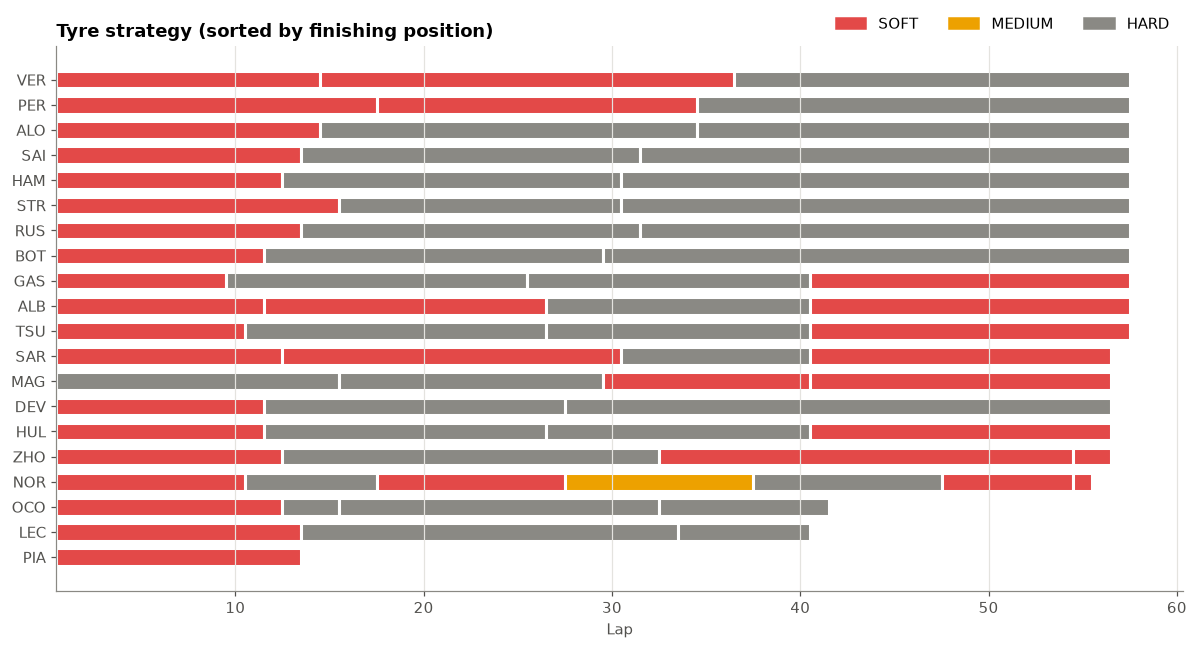

In [33]:
stints = (laps.groupby(["Driver", "Stint", "Compound"], observed=True)
              .agg(first_lap=("LapNumber", "min"), last_lap=("LapNumber", "max"),
                   start_life=("TyreLife", "min"), fresh=("FreshTyre", "first"))
              .reset_index())
finish_order = session.results.sort_values("Position")["Abbreviation"].tolist()

fig, ax = plt.subplots(figsize=(11, 6))
for i, drv in enumerate(finish_order):
    for _, s in stints[stints["Driver"] == drv].iterrows():
        ax.barh(i, s["last_lap"] - s["first_lap"] + 1, left=s["first_lap"] - 0.5, height=0.7,
                color=COMPOUND_COLORS.get(s["Compound"], "#cccccc"), edgecolor="white", linewidth=2)
ax.set_yticks(range(len(finish_order)), finish_order)
ax.invert_yaxis(); ax.grid(axis="y", visible=False)
ax.set_xlabel("Lap"); ax.set_title("Tyre strategy (sorted by finishing position)", loc="left")
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in list(COMPOUND_COLORS.values())[:3]]
ax.legend(handles, list(COMPOUND_COLORS)[:3], ncol=3, loc="lower right", bbox_to_anchor=(1, 1.0))
plt.tight_layout()

In [34]:
# Not every stint starts on a new tyre: start_life > 1 / fresh == False means a used set from qualifying.
stints[stints["Driver"].isin(DRIVER_COLORS)]

,Driver,Stint,Compound,first_lap,last_lap,start_life,fresh
4,ALO,1.0,SOFT,1.0,14.0,4.0,False
5,ALO,2.0,HARD,15.0,34.0,1.0,True
6,ALO,3.0,HARD,35.0,57.0,1.0,True
17,HAM,1.0,SOFT,1.0,12.0,4.0,False
18,HAM,2.0,HARD,13.0,30.0,1.0,True
19,HAM,3.0,HARD,31.0,57.0,1.0,True
63,VER,1.0,SOFT,1.0,14.0,4.0,False
64,VER,2.0,SOFT,15.0,36.0,1.0,False
65,VER,3.0,HARD,37.0,57.0,1.0,True


## 5 · Lap time vs tyre age - the raw signal behind the degradation index

Clean, green-flag laps only, one panel per compound (compounds with < 50 laps hidden).

The pooled clouds are **messy and non-monotonic**: they mix 20 drivers of different
pace, different stints, and different fuel loads (an old tyre late in the race also
means a light car). Pooling hides the degradation signal. That's exactly why
`tire_degradation_index` regresses **within one (Driver, Stint)** instead of across everyone.

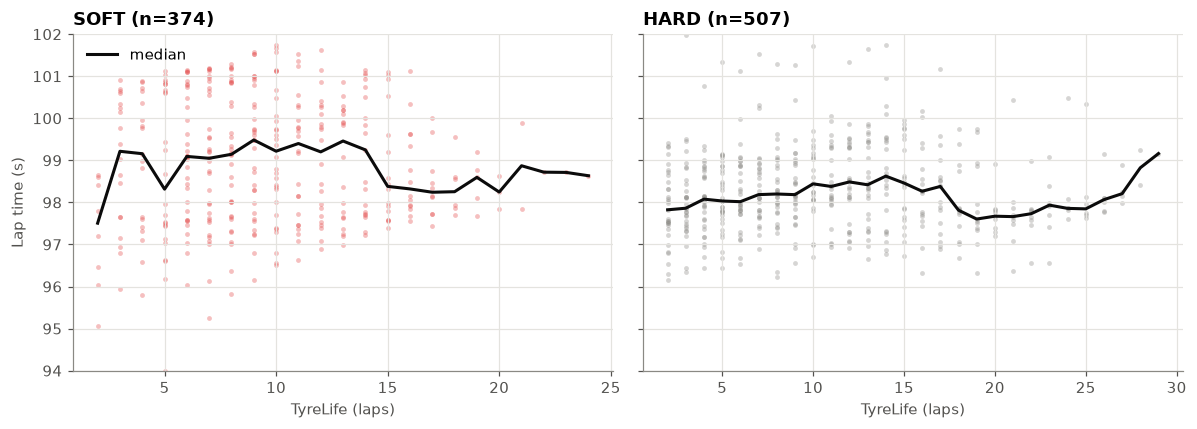

In [35]:
counts = clean_green["Compound"].value_counts()
compounds = [c for c in ["SOFT", "MEDIUM", "HARD"] if counts.get(c, 0) >= 50]
fig, axes = plt.subplots(1, len(compounds), sharey=True, figsize=(11, 4))
for ax, comp in zip(np.atleast_1d(axes), compounds):
    d = clean_green[clean_green["Compound"] == comp]
    ax.scatter(d["TyreLife"], d["LapTime_s"], s=10, alpha=0.35, color=COMPOUND_COLORS[comp], linewidth=0)
    med = d.groupby("TyreLife")["LapTime_s"].median()
    ax.plot(med.index, med.values, color="#0b0b0b", linewidth=2, label="median")
    ax.set_title(f"{comp} (n={len(d)})", loc="left"); ax.set_xlabel("TyreLife (laps)")
np.atleast_1d(axes)[0].set_ylabel("Lap time (s)")
np.atleast_1d(axes)[0].legend(loc="upper left")
plt.ylim(94, 102); plt.tight_layout()

**Now one stint at a time.** Within a single stint, lap time vs tyre age is much
cleaner. The slope you see mixes tyre wear (+) with fuel burn (−). After you
implement `fuel_corrected_lap_time`, add `+ 0.06 * (57 - LapNumber)`-style correction here and
watch every line tilt further upward: that remaining tilt is the degradation.

VER stint 1 (SOFT, 11 laps): raw slope +0.066 s/lap
VER stint 2 (SOFT, 20 laps): raw slope +0.001 s/lap
VER stint 3 (HARD, 18 laps): raw slope +0.013 s/lap
HAM stint 1 (SOFT, 9 laps): raw slope +0.198 s/lap
HAM stint 2 (HARD, 16 laps): raw slope -0.019 s/lap
HAM stint 3 (HARD, 24 laps): raw slope +0.033 s/lap
ALO stint 1 (SOFT, 11 laps): raw slope +0.162 s/lap
ALO stint 2 (HARD, 18 laps): raw slope +0.002 s/lap
ALO stint 3 (HARD, 20 laps): raw slope +0.024 s/lap


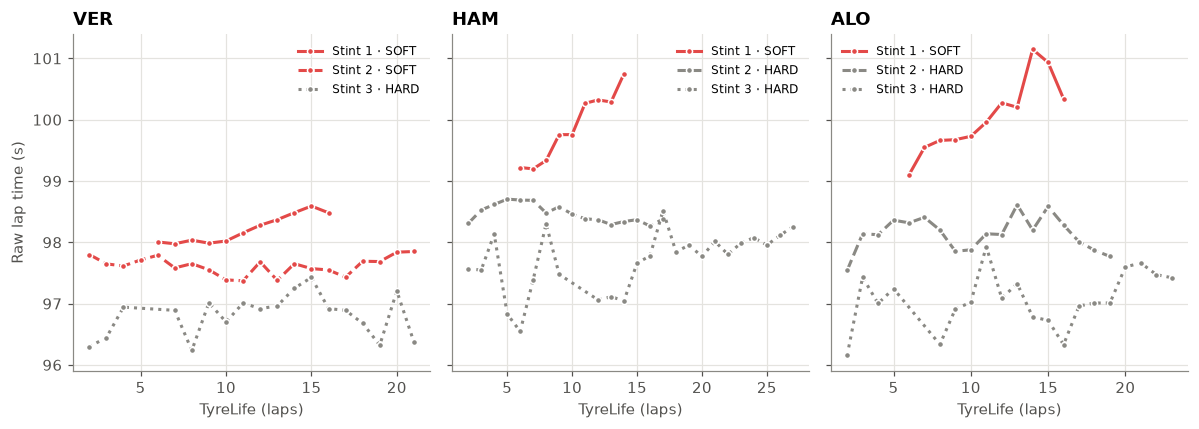

In [36]:
fig, axes = plt.subplots(1, 3, sharey=True, figsize=(11, 4))
for ax, (drv, color) in zip(axes, DRIVER_COLORS.items()):
    d = clean_green[clean_green["Driver"] == drv]
    for stint, g in d.groupby("Stint"):
        g = g.sort_values("LapNumber")
        comp = g["Compound"].iloc[0]
        ax.plot(g["TyreLife"], g["LapTime_s"], color=COMPOUND_COLORS[comp], marker="o", markersize=4,
                linestyle=["-", "--", ":", "-."][(int(stint) - 1) % 4],
                markeredgecolor="white", markeredgewidth=1, label=f"Stint {int(stint)} · {comp}")
        slope = np.polyfit(g["TyreLife"], g["LapTime_s"], 1)[0] if len(g) > 2 else np.nan
        print(f"{drv} stint {int(stint)} ({comp}, {len(g)} laps): raw slope {slope:+.3f} s/lap")
    ax.set_title(drv, loc="left"); ax.set_xlabel("TyreLife (laps)"); ax.legend(fontsize=8)
axes[0].set_ylabel("Raw lap time (s)")
plt.tight_layout()

## 6 · Weather - ~1 sample per minute, on a different clock than laps

These are the inputs to `track_temp_delta` and `air_density`. Note the units:
`Pressure` in **hPa (mbar)**, `Humidity` in **%**, temperatures in **°C**.
Weather timestamps never line up with lap starts, which is why Phase 1 uses `merge_asof`.

Bahrain is a **twilight race**: the sun sets around the start, so the track *cools*
by ~6 °C over the race. Expect `TrackTempDelta_C` to be mostly negative here, the
opposite of a hot afternoon race.

(161, 9)


,Time,AirTemp,Humidity,Pressure,TrackTemp,WindDirection,WindSpeed,minutes
count,161,161.00,161.00,161.00,161.00,161.00,161.00,161.00
mean,0 days 01:20:45.769863354,27.43,21.50,1016.86,31.01,177.13,0.68,80.76
std,0 days 00:46:37.427624514,1.06,2.06,0.27,1.77,69.82,0.44,46.62
min,0 days 00:00:45.438000,26.20,18.00,1016.50,28.70,0.00,0.00,0.76
25%,0 days 00:40:45.629000,26.60,21.00,1016.70,29.60,171.00,0.40,40.76
50%,0 days 01:20:45.867000,27.10,21.00,1016.90,30.60,184.00,0.60,80.76
75%,0 days 02:00:45.933000,28.10,22.00,1017.00,32.20,207.00,0.80,120.77
max,0 days 02:40:46.061000,29.80,28.00,1017.50,35.10,352.00,2.20,160.77


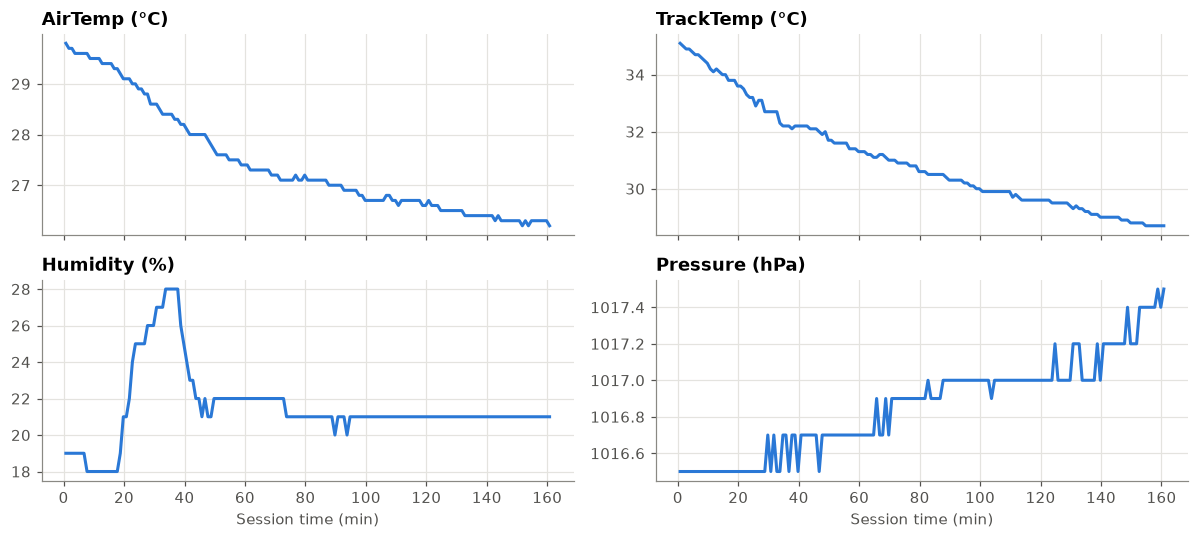

In [37]:
weather = pd.DataFrame(session.weather_data)
weather["minutes"] = weather["Time"].dt.total_seconds() / 60
print(weather.shape)
display(weather.describe().round(2))

cols = [("AirTemp", "°C"), ("TrackTemp", "°C"), ("Humidity", "%"), ("Pressure", "hPa")]
fig, axes = plt.subplots(2, 2, sharex=True, figsize=(11, 5))
for ax, (col, unit) in zip(axes.flat, cols):
    ax.plot(weather["minutes"], weather[col], color="#2a78d6")
    ax.set_title(f"{col} ({unit})", loc="left")
for ax in axes[1]:
    ax.set_xlabel("Session time (min)")
plt.tight_layout()

In [38]:
# How regular is the weather clock? (minutes between consecutive samples)
weather["Time"].diff().dt.total_seconds().div(60).describe().round(3)

count    160.000
mean       1.000
std        0.000
min        0.999
25%        1.000
50%        1.000
75%        1.000
max        1.001
Name: Time, dtype: float64

## 7 · Car telemetry - what `micro_sector_deltas` will consume

`lap.get_telemetry()` merges car data (speed, throttle, …) with position data and
adds `Distance`. It is **sampled in time, irregularly** - so two laps never have a
sample at the same metre of track, and we need `np.interp` to compare them.

In [39]:
ver_lap = session.laps.pick_drivers("VER").pick_fastest()
ham_lap = session.laps.pick_drivers("HAM").pick_fastest()
ver_tel, ham_tel = ver_lap.get_telemetry(), ham_lap.get_telemetry()
print("VER fastest:", ver_lap["LapTime"], "| HAM fastest:", ham_lap["LapTime"])
print("telemetry shape:", ver_tel.shape)
ver_tel[["Time", "Distance", "Speed", "RPM", "nGear", "Throttle", "Brake", "DRS", "X", "Y"]].head(8)

VER fastest: 0 days 00:01:36.236000 | HAM fastest: 0 days 00:01:36.546000
telemetry shape: (726, 18)


,Time,Distance,Speed,RPM,nGear,Throttle,Brake,DRS,X,Y
2,0 days 00:00:00,0.010802,284.412500,11271.212513,7,100.0,False,0,-382.256646,1221.030661
3,0 days 00:00:00.062000,4.920572,284.670833,11283.870820,7,100.0,False,0,-380.000000,1270.000000
4,0 days 00:00:00.141000,11.190000,285.000000,11300.000000,7,100.0,False,0,-377.234236,1332.493638
5,0 days 00:00:00.262000,20.821555,285.864285,11338.460694,7,100.0,False,0,-373.000000,1429.000000
6,0 days 00:00:00.421000,33.512222,287.000000,11389.000000,7,100.0,False,0,-366.815026,1558.804999
7,0 days 00:00:00.582000,46.377076,287.670833,11421.870820,7,100.0,False,0,-360.000000,1700.000000
8,0 days 00:00:00.661000,52.712222,288.000000,11438.000000,7,100.0,False,0,-356.520828,1775.203847
9,0 days 00:00:00.821000,65.601111,290.000000,11500.000000,7,100.0,False,0,-349.371109,1935.559335


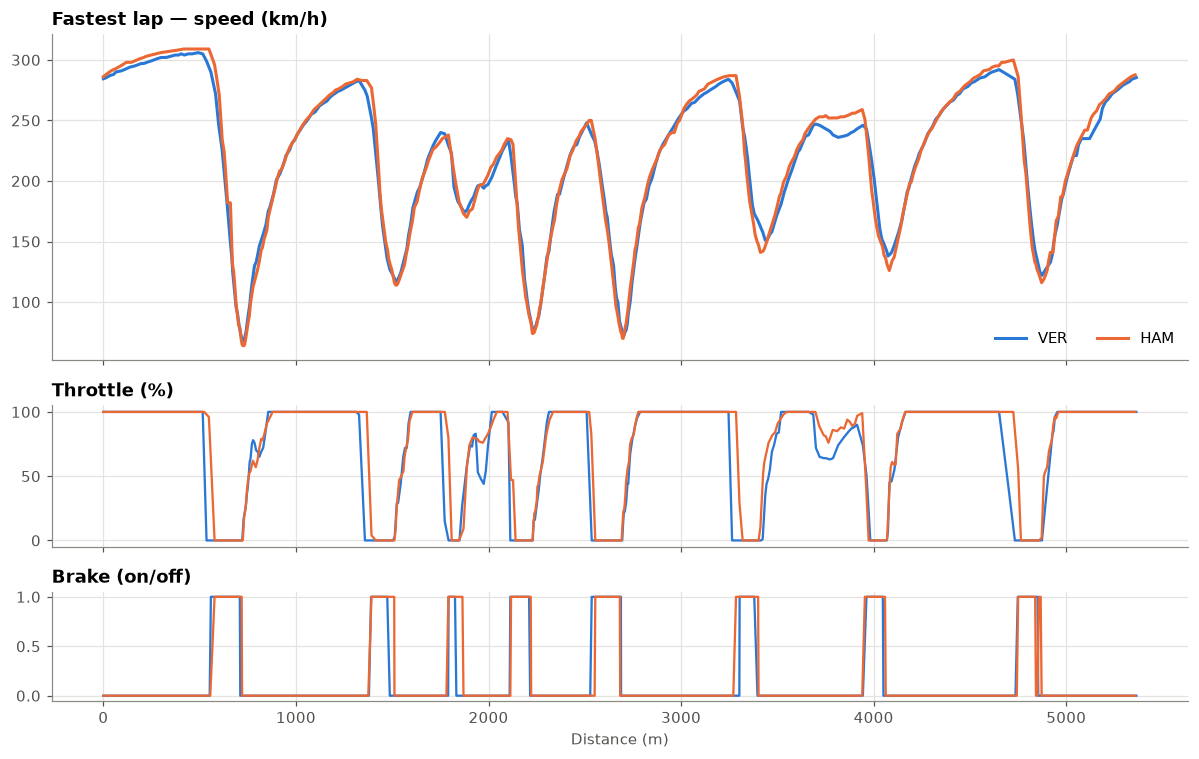

In [40]:
fig, axes = plt.subplots(3, 1, sharex=True, figsize=(11, 7), height_ratios=[3, 1.3, 1])
for tel, drv in [(ver_tel, "VER"), (ham_tel, "HAM")]:
    c = DRIVER_COLORS[drv]
    axes[0].plot(tel["Distance"], tel["Speed"], color=c, label=drv)
    axes[1].plot(tel["Distance"], tel["Throttle"], color=c, linewidth=1.5)
    axes[2].plot(tel["Distance"], tel["Brake"].astype(int), color=c, linewidth=1.5)
axes[0].set_title("Fastest lap — speed (km/h)", loc="left"); axes[0].legend(ncol=2)
axes[1].set_title("Throttle (%)", loc="left")
axes[2].set_title("Brake (on/off)", loc="left"); axes[2].set_xlabel("Distance (m)")
plt.tight_layout()

count    725.000
mean       0.133
std        0.083
min        0.001
25%        0.060
50%        0.138
75%        0.200
max        0.382


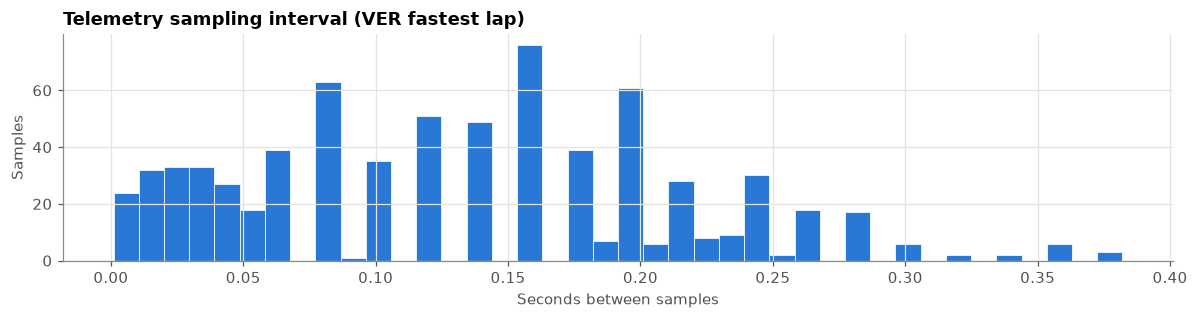

In [41]:
# Irregular sampling: seconds between consecutive telemetry samples.
dt = ver_tel["Time"].dt.total_seconds().diff().dropna()
fig, ax = plt.subplots(figsize=(11, 3))
ax.hist(dt, bins=40, color="#2a78d6", edgecolor="white", linewidth=0.5)
ax.set_xlabel("Seconds between samples"); ax.set_ylabel("Samples")
ax.set_title("Telemetry sampling interval (VER fastest lap)", loc="left")
plt.tight_layout()
print(dt.describe().round(3).to_string())

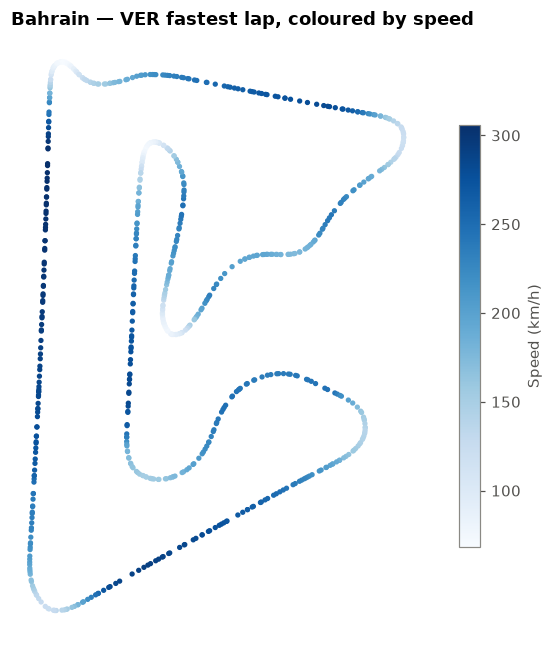

In [42]:
# Track map from X/Y position, coloured by speed — the 'shape' micro-sectors are cut from.
fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(ver_tel["X"], ver_tel["Y"], c=ver_tel["Speed"], cmap="Blues", s=6)
ax.set_aspect("equal"); ax.axis("off")
fig.colorbar(sc, ax=ax, shrink=0.7, label="Speed (km/h)")
ax.set_title("Bahrain — VER fastest lap, coloured by speed", loc="left")
plt.tight_layout()

## 8 · Results table (per driver)

Not used yet, but useful later (grid position, finishing status, DNFs).

In [43]:
session.results[["Abbreviation", "TeamName", "GridPosition", "Position", "Status", "Points", "Laps"]]

,Abbreviation,TeamName,GridPosition,Position,Status,Points,Laps
1,VER,Red Bull Racing,1.0,1.0,Finished,25.0,57.0
11,PER,Red Bull Racing,2.0,2.0,Finished,18.0,57.0
14,ALO,Aston Martin,5.0,3.0,Finished,15.0,57.0
55,SAI,Ferrari,4.0,4.0,Finished,12.0,57.0
44,HAM,Mercedes,7.0,5.0,Finished,10.0,57.0
18,STR,Aston Martin,8.0,6.0,Finished,8.0,57.0
63,RUS,Mercedes,6.0,7.0,Finished,6.0,57.0
77,BOT,Alfa Romeo,12.0,8.0,Finished,4.0,57.0
10,GAS,Alpine,20.0,9.0,Finished,2.0,57.0
23,ALB,Williams,15.0,10.0,Finished,1.0,57.0
